### 1. Solve the XOR problem.

In [2]:
import numpy as np

def AND (x1, x2) :
    x = np.array([x1, x2])
    w = np.array([1.0, 1.0])
    b = -1.5

    tmp = np.sum(w * x) + b

    if (tmp < 0) : return 0
    else : return 1


def NAND (x1, x2) :
    x = np.array([x1, x2])
    w = np.array([-1.0, -1.0])
    b = 1.5

    tmp = np.sum(w * x) + b

    if (tmp < 0) : return 0
    else : return 1


def OR (x1, x2) :
    x = np.array([x1, x2])
    w = np.array([1.0, 1.0])
    b = -0.5

    tmp = np.sum(w * x) + b

    if (tmp < 0) : return 0
    else : return 1

In [3]:
assert (AND(0, 0) == 0)
assert (AND(0, 1) == 0)
assert (AND(1, 0) == 0)
assert (AND(1, 1) == 1)

assert NAND(0, 0) == 1
assert NAND(0, 1) == 1
assert NAND(1, 0) == 1
assert NAND(1, 1) == 0

assert OR(0, 0) == 0
assert OR(0, 1) == 1
assert OR(1, 0) == 1
assert OR(1, 1) == 1

In [5]:
'''
Task Cell
'''

def XOR (x1, x2) :

    # AND, NAND, OR
    s1 = AND(x1,x2)
    s2 = OR(x1,x2)

    x = np.array([s1, s2])
    w = np.array([-1,1])        # fill the weight list
    b = -0.5                    # fill the bias scalar

    tmp = np.sum(w * x) + b

    if (tmp < 0) : return 0
    else : return 1

In [6]:
assert (XOR(0, 0) == 0)
assert (XOR(1, 0) == 1)
assert (XOR(0, 1) == 1)
assert (XOR(1, 1) == 0)

### 2. Weight and Bias shape

In [7]:
# ===== 0) Setup =====
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [8]:
layer = nn.Linear(              # Fully Connected Layer
    in_features = 3,              # 입력 차원(이전 레이어 뉴런 수) = 3
    out_features = 2,             # 출력 차원(현재 레이어 뉴런 수) = 2
    bias = True                   # bias를 사용할지 여부 (기본 True)
)

print("=== weight ===")
print("shape :: ", layer.weight.shape)          # weight 텐서의 shape :: (out_features, in_features)
print(layer.weight)
print()

print("=== bias === ")
print("shape :: ", layer.bias.shape)              # bias 텐서의 shape :: (out_features,)
print(layer.bias)
print()

# Sample Data
print("Sample Data")
x = torch.randn(3)
y = layer(x)
print("x.shape ::", x.shape, x)
print("y.shape :: ", y.shape, y)

=== weight ===
shape ::  torch.Size([2, 3])
Parameter containing:
tensor([[-0.0043,  0.3097, -0.4752],
        [-0.4249, -0.2224,  0.1548]], requires_grad=True)

=== bias === 
shape ::  torch.Size([2])
Parameter containing:
tensor([-0.0114,  0.4578], requires_grad=True)

Sample Data
x.shape :: torch.Size([3]) tensor([-1.0845, -1.3986,  0.4033])
y.shape ::  torch.Size([2]) tensor([-0.6316,  1.2920], grad_fn=<ViewBackward0>)


### 3. Forward Propagation

In [9]:
# tiny network: manual vs pytorch
torch.manual_seed(0)

fc1 = nn.Linear(2, 3, bias=True)
fc2 = nn.Linear(3, 2, bias=True)

with torch.no_grad():
    fc1.weight.copy_(torch.tensor([[0.1, 0.2],
                                   [0.3, 0.4],
                                   [0.5, 0.6]]))  # (out=3,in=2)
    fc1.bias.copy_(torch.tensor([0.01, 0.02, 0.03]))
    fc2.weight.copy_(torch.tensor([[0.7, 0.8, 0.9],
                                   [1.0, 1.1, 1.2]]))  # (out=2,in=3)
    fc2.bias.copy_(torch.tensor([0.04, 0.05]))

x = torch.tensor([[1.0, 0.5]])  # (1,2)

In [10]:
# PyTorch
h = fc1(x)
out = fc2(h)

# By Hand
a1 = x @ fc1.weight.T + fc1.bias
out_manual = a1 @ fc2.weight.T + fc2.bias

print("PyTorch out:", out)
print("Manual  out:", out_manual)
print("Same?", torch.allclose(out, out_manual))

PyTorch out: tensor([[1.3500, 1.8280]], grad_fn=<AddmmBackward0>)
Manual  out: tensor([[1.3500, 1.8280]], grad_fn=<AddBackward0>)
Same? True


In [12]:
'''
Task Cell
'''

# PyTorch
h = torch.sigmoid(fc1(x))           # activation function
out = fc2(h)

# By Hand
a1 = x @ fc1.weight.T + fc1.bias
h_manual = torch.sigmoid(a1)                       # Apply activation function
out_manual = h_manual @ fc2.weight.T + fc2.bias

print("PyTorch out:", out)
print("Manual  out:", out_manual)
print("Same?", torch.allclose(out, out_manual))

assert(torch.allclose(out, out_manual))

PyTorch out: tensor([[1.5551, 2.1278]], grad_fn=<AddmmBackward0>)
Manual  out: tensor([[1.5551, 2.1278]], grad_fn=<AddBackward0>)
Same? True


### 4. Loss Function

In [13]:
import math

def cross_entropy (p, q, eps=1e-12) :

    ce = 0.0
    for pi, qi in zip(p, q) :
        qi = max(qi, eps)           # log(0) 방지
        ce += -pi * math.log(qi)    # ln 사용
    return ce

def kl_divergence (p, q, eps=1e-12) :

    kl = 0.0
    for pi, qi in zip(p, q):
        pi = max(pi, eps)           # log(0) 방지(0*log(0/.) 처리용)
        qi = max(qi, eps)
        kl += pi * math.log(pi / qi)
    return kl

In [14]:
# 예시: 고양이/강아지
p = [1.0, 0.0]      # true distribution (cat, dog)
q = [0.9, 0.1]      # model prediction distribution

ce = cross_entropy(p, q)
kl = kl_divergence(p, q)

print("p (true) =", p)
print("q (pred) =", q)
print("Cross Entropy H(p,q) =", ce)
print("KL Divergence D_KL(p||q) =", kl)

p (true) = [1.0, 0.0]
q (pred) = [0.9, 0.1]
Cross Entropy H(p,q) = 0.10536051565782628
KL Divergence D_KL(p||q) = 0.10536051563249792


In [15]:
# 예시: 고양이/강아지
p = [1.0, 0.0]      # true distribution (cat, dog)
q = [0.5, 0.5]      # model prediction distribution

ce = cross_entropy(p, q)
kl = kl_divergence(p, q)

print("p (true) =", p)
print("q (pred) =", q)
print("Cross Entropy H(p,q) =", ce)
print("KL Divergence D_KL(p||q) =", kl)

p (true) = [1.0, 0.0]
q (pred) = [0.5, 0.5]
Cross Entropy H(p,q) = 0.6931471805599453
KL Divergence D_KL(p||q) = 0.6931471805330074


In [17]:
'''
Task Cell
'''

# 예시: 고양이/강아지
p = [1.0, 0.0]
q = [1.0, 0.0]               # Make loss = 0

ce = cross_entropy(p, q)
kl = kl_divergence(p, q)

print("p (true) =", p)
print("q (pred) =", q)
print("Cross Entropy H(p,q) =", ce)
print("KL Divergence D_KL(p||q) =", kl)

assert(ce == 0.0)
assert(kl == 0.0)

p (true) = [1.0, 0.0]
q (pred) = [1.0, 0.0]
Cross Entropy H(p,q) = 0.0
KL Divergence D_KL(p||q) = 0.0


### 5. Learning Rate

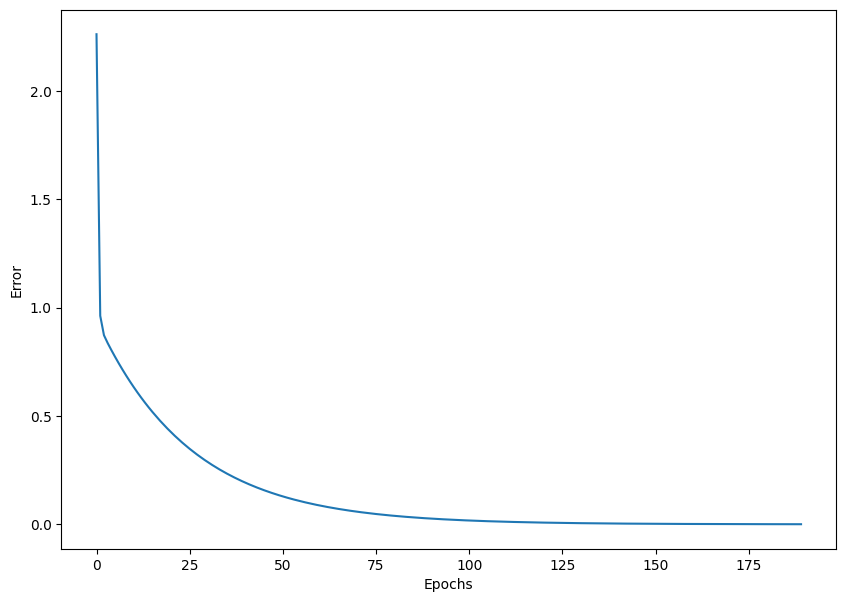

In [24]:
'''
Task Cell
'''

# 최대 반복 횟수
num_epoch = 500

# 학습율 (learning_rate)
# change the value [10.0, 0.1, 0.0001]
learning_rate = 0.5

import numpy as np

errors = []
# random 한 값으로 w, b를 초기화 합니다.
w = np.random.uniform(low=0.0, high=1.0)
b = np.random.uniform(low=0.0, high=1.0)

for epoch in range(num_epoch):
    y_hat = x * w + b

    error = ((y_hat - y)**2).mean()
    if error < 0.0005:
        break

    w = w - learning_rate * ((y_hat - y) * x).mean()
    b = b - learning_rate * (y_hat - y).mean()

    errors.append(error.item())

plt.figure(figsize=(10, 7))
plt.plot(errors)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

### 6. Optimizer

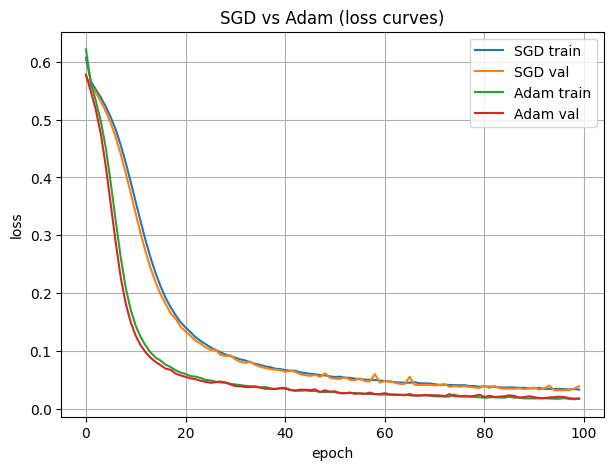

In [25]:
def make_circle(n=2000, r=0.6):
    X = np.random.uniform(-1.0, 1.0, size=(n, 2)).astype(np.float32)
    y = (np.sqrt((X**2).sum(axis=1)) < r).astype(np.float32)
    return torch.tensor(X), torch.tensor(y).unsqueeze(1)

X, y = make_circle(n=3000, r=0.6)
X_train, y_train = X[:2500], y[:2500]
X_val, y_val = X[2500:], y[2500:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)

def train_once(optim_name="adam", lr=1e-3, epochs=30):
    model = nn.Sequential(
        nn.Linear(2, 64), nn.ReLU(),
        nn.Linear(64, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)
    crit = nn.BCEWithLogitsLoss()
    opt = torch.optim.SGD(model.parameters(), lr=lr) if optim_name=="sgd" else torch.optim.Adam(model.parameters(), lr=lr)

    tr, va = [], []
    for _ in range(epochs):
        model.train()
        tot = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0)
        tr.append(tot / len(train_loader.dataset))

        model.eval()
        tot = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                tot += crit(model(xb), yb).item() * xb.size(0)
        va.append(tot / len(val_loader.dataset))
    return tr, va

# Try to change
sgd_tr, sgd_va = train_once("sgd", lr = 0.1, epochs = 100)
adam_tr, adam_va = train_once("adam", lr = 0.001, epochs = 100)

plt.figure(figsize=(7,5))
plt.plot(sgd_tr, label="SGD train")
plt.plot(sgd_va, label="SGD val")
plt.plot(adam_tr, label="Adam train")
plt.plot(adam_va, label="Adam val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("SGD vs Adam (loss curves)")
plt.legend()
plt.grid(True)
plt.show()

### Task. MNIST

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [27]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.69MB/s]


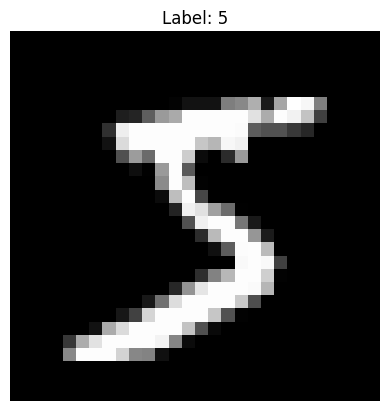

In [28]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

# change index
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

In [29]:
images, labels = next(iter(train_loader))

print("images shape:", images.shape)   # [batch_size, 1, 28, 28]
print("labels shape:", labels.shape)   # [batch_size]
print("first 5 labels:", labels[:5])

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
first 5 labels: tensor([5, 0, 4, 1, 9])


hidden layer : `128`차원   
activation function : `ReLU`   
Loss Function : `CrossEntropyLoss`  
Optimizer : `Adam`  

In [35]:
model = nn.Sequential(
    nn.Flatten(),                  # (1) 이미지를 1차원으로 펼치기
    nn.Linear(28 * 28, 128),  # (2) hidden size 채우기
    nn.ReLU(),                 # (3) activation function
    nn.Linear(128, 10)       # (4) 출력 클래스 수
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [36]:
criterion = nn.CrossEntropyLoss()                             # Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)    # Optimizer

In [45]:
num_epochs = 5

for epoch in range (num_epochs) :
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        outputs = model(images)                  # 예측
        loss = criterion(outputs, labels)        # loss 계산

        optimizer.zero_grad()                 # (1) 이전 gradient 초기화 :: zero_grad
        loss.backward()                      # (2) gradient 계산       :: backward
        optimizer.step()                 # (3) 가중치 업데이트        :: step

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.0675
Epoch [2/5], Loss: 0.0535
Epoch [3/5], Loss: 0.0426
Epoch [4/5], Loss: 0.0342
Epoch [5/5], Loss: 0.0271


In [46]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)   # 가장 큰 값 선택 :: argmax

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.22%
